# Adaptive RAG 구현

## 실습 목표
---
Adaptive RAG 챗봇을 구현하여 사용자 입력이 관련 문서와 일치하지 않는 경우 웹 검색을 통해 답변을 생성합니다.

## 실습 목차
---
1. **웹 검색 API 통합**: 웹 검색 API를 활용해서 필요한 정보를 검색하는 모듈을 구현합니다.

2. **Adaptive RAG 구현**: Self-RAG 챗봇에 웹 검색 기능을 추가하여 Adaptive RAG 챗봇을 구현하고 사용합니다.

## 0. 환경 설정
필요한 라이브러리를 불러옵니다.

In [2]:
import contextlib
import io
import os
from typing import Optional

import pandas as pd
from dotenv import load_dotenv
from langchain_chroma import Chroma
from langchain_community.document_loaders import PyPDFLoader
from langchain_core.output_parsers import JsonOutputParser, StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_ollama import OllamaEmbeddings
from langchain_openai import ChatOpenAI
from langchain_tavily import TavilySearch
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import END, START, StateGraph
from typing_extensions import TypedDict

load_dotenv()

/var/folders/px/v7_qzrl907d919ql0sn3f74r0000gn/T/ipykernel_25687/111890270.py:9: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

ChatGPT API(`.env`의 `MODEL_NAME`)로 답변 생성용 `llm`을 만들고, 여기에 JSON 출력을 강제하는 `.bind()`를 적용해 라우팅/평가 전용 `route_llm`을 만듭니다. 임베딩은 Ollama의 `qwen3-embedding:0.6b`를 사용합니다.

In [3]:
llm = ChatOpenAI(
    model=os.environ["MODEL_NAME"],
    base_url=os.environ["BASE_URL"],
    api_key=os.environ["OPENAI_API_KEY"],
    temperature=0,
)
# llm.bind(...)로 JSON 강제 출력 옵션을 추가해 route_llm을 만듭니다. (동일 모델, 다른 출력 형식)
route_llm = llm.bind(response_format={"type": "json_object"})
embeddings = OllamaEmbeddings(model="qwen3-embedding:0.6b")

Graph State를 정의합니다.

In [4]:
class State(TypedDict):
    # 그래프 상태의 속성을 정의합니다.
    # 질문, 라우팅 경로, LLM이 생성한 텍스트, 데이터, 코드를 저장합니다.
    question: str
    route: Optional[str]
    generation: str
    data: str
    code: str

## 1. 웹 검색 API 통합
---
웹 검색 API를 활용해서 필요한 정보를 검색하는 모듈을 구현합니다.

Tavily Search API Key를 등록합니다.

1. 먼저, 아래 링크에 접속한 후 'Sign-in' 버튼을 눌러 로그인 화면으로 이동합니다.
   - https://app.tavily.com/sign-in
2. 여러분의 Tavily 계정으로 로그인한 후, 아래 링크에 접속하여 default API Key를 복사합니다.
   - https://app.tavily.com/home
3. 이 노트북과 같은 폴더에 있는 `.env` 파일을 열어 `TAVILY_API_KEY=` 뒤에 복사한 키를 붙여넣고 저장합니다. (파일이 없다면 `.env.example`을 복사해서 `.env`로 이름을 바꾼 뒤 사용하세요.)

In [5]:
# API Key는 코드에 직접 입력하지 않고 .env 파일에서 불러옵니다.
# (.env 파일의 TAVILY_API_KEY에 키를 넣어두면 load_dotenv()가 자동으로 환경 변수에 등록합니다.)
assert os.environ.get("TAVILY_API_KEY"), ".env 파일에 TAVILY_API_KEY를 설정해주세요."

Tavily API 설정이 완료되었으면, 간단한 검색 기능을 구현합니다. 

Note. 간단한 구현을 위해 `max_results` 인자를 1로 설정하여 하나의 문서만 검색되도록 설정했습니다.<br>
향후 고도화 과정에서 여러 문서를 검색하고, Self-RAG 와 유사하게 문서에 순위를 매기는 기능을 추가할 수 있을 것입니다.

In [6]:
tavily_search_tool = TavilySearch(max_results=1)

def retrieve_web(state: State) -> State:
    print("[web_search] 웹 검색 중...")
    question = state["question"]
    # TavilySearch는 {"results": [{"content": ...}, ...]} 형태의 dict를 반환합니다.
    results = tavily_search_tool.invoke({"query": question})["results"]
    for r in results:
        print(f"[web_search] {r.get('url', '출처 미상')} | {r['content'][:80]}...")

    # 다른 경로(retrieval)와 동일하게 문자열로 합쳐서 저장합니다.
    data = "\n".join(r["content"] for r in results)
    print(f"[web_search] 검색된 내용 미리보기: {data[:100]}")
    return {"question": question, "data": data}

검색 결과를 확인해봅시다.

In [7]:
retrieved_state = retrieve_web({"question": "LangChain과 LlamaIndex의 특징과 차이점은 무엇인가요?"})
print(retrieved_state["data"][:300])

[web_search] 웹 검색 중...


[web_search] https://www.ibm.com/kr-ko/think/topics/llamaindex-vs-langchain | # LlamaIndex 및 LangChain 비교: 차이점은 무엇인가요? LlamaIndex와 LangChain은 검색 증강 생성(RAG) 시스...
[web_search] 검색된 내용 미리보기: # LlamaIndex 및 LangChain 비교: 차이점은 무엇인가요? LlamaIndex와 LangChain은 검색 증강 생성(RAG) 시스템의 생성과 구현을 용이하게 하는 두
# LlamaIndex 및 LangChain 비교: 차이점은 무엇인가요? LlamaIndex와 LangChain은 검색 증강 생성(RAG) 시스템의 생성과 구현을 용이하게 하는 두 가지 플랫폼입니다. LlamaIndex는 간소화된 검색을 위해 구축되었으며 LangChain은 다양한 사용 사례를 지원하는 다목적 모듈식 플랫폼입니다. LlamaIndex는 텍스트 기반 데이터 소스에서 인덱싱, 데이터 수집 및 정보 검색에 중점을 두므로 보다 간단한 워크플로와 간단한 AI 애플리케이션에 이상적입니다. RAG는 생성형 AI 모델이 다른 방법


## 2. Adaptive RAG 구현
---
Self-RAG 챗봇에 웹 검색 기능을 추가하여 Adaptive RAG 챗봇을 구현하고 사용합니다.

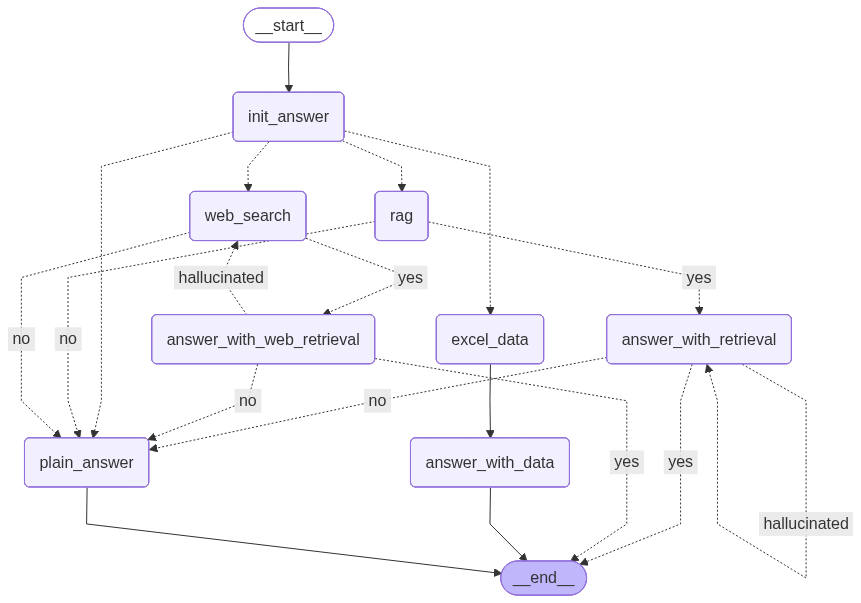

### 2.1. Self-RAG 챗봇 구현
간략화한 Self-RAG 챗봇을 구현합니다. 이를 위해 검색 과정에서의 문서와 답변을 평가하는 함수를 정의합니다.

In [8]:
# route_llm은 JSON으로만 답하므로 JsonOutputParser로 바로 파싱합니다. (is_data_relevant/is_answer_supportive/is_answer_useful는
# 실습2에서 이미 입출력 예시를 보여줬으므로 여기서는 생략합니다.)
relevant_judge_prompt = ChatPromptTemplate.from_messages([
    ("system", """당신은 검색된 문서와 사용자의 질문의 연관성을 평가하는 평가자입니다.
다음은 검색된 문서입니다: \n{data}\n.
문서와 사용자가 입력할 질문이 연관이 있다면 true, 그렇지 않다면 false를 선택하세요.
답변은 'relevant' key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""),
    ("human", "{question}"),
])
relevance_chain = relevant_judge_prompt | route_llm | JsonOutputParser()

def is_data_relevant(state: State) -> dict:
    # 검색된 문서(data)가 질문과 관련 있는지 route_llm이 true/false로 판단합니다.
    result = relevance_chain.invoke({"question": state["question"], "data": state["data"]})
    print(f"[is_data_relevant] {result}")
    return result


supportive_judge_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 AI의 답변이 사용자의 질문에 대한 해답인지 평가하는 평가자입니다."),
    ("human", """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자의 질문에 대한 해답이면 true, 아니라면 false를 선택하세요.
'answer' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""),
])
supportive_chain = supportive_judge_prompt | route_llm | JsonOutputParser()

def is_answer_supportive(state: State) -> dict:
    # AI 답변이 질문에 대한 해답인지 route_llm이 true/false로 판단합니다.
    result = supportive_chain.invoke({"question": state["question"], "generation": state["generation"]})
    print(f"[is_answer_supportive] {result}")
    return result


useful_judge_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 AI의 답변이 사용자에게 유용한지 평가하는 평가자입니다."),
    ("human", """사용자의 질문: {question}
AI의 답변: {generation}
AI의 답변이 사용자에게 유용하다면 true, 아니라면 false를 선택하세요.
'useful' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""),
])
useful_chain = useful_judge_prompt | route_llm | JsonOutputParser()

def is_answer_useful(state: State) -> dict:
    # AI 답변이 사용자에게 유용한지 route_llm이 true/false로 판단합니다.
    result = useful_chain.invoke({"question": state["question"], "generation": state["generation"]})
    print(f"[is_answer_useful] {result}")
    return result

In [9]:
hallucination_judge_prompt = ChatPromptTemplate.from_messages([
    ("system", "당신은 주어진 근거 문서를 바탕으로 AI의 답변이 진실인지 여부를 평가하는 평가자입니다."),
    ("human", """근거 문서: {docs}
AI의 답변: {generation}
근거 문서를 바탕으로 AI의 답변이 진실이라면 true, 아니라면 false를 선택하세요.
'answer' key 하나만 있는 JSON 형식으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""),
])
hallucination_chain = hallucination_judge_prompt | route_llm | JsonOutputParser()

def is_hallucinated(state: State) -> dict:
    # AI 답변이 근거 문서에 부합하는(진실된) 답변인지 route_llm이 true/false로 판단합니다.
    result = hallucination_chain.invoke({"generation": state["generation"], "docs": state["data"]})
    print(f"[is_hallucinated] {result}")
    return result

데이터를 불러오고, 유틸리티 함수를 정의합니다.

In [10]:
excel_data_name = "한국지능정보사회진흥원_인공지능 학습용 데이터 구축 현황_20210104.csv"
pdf_data_name = "RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf"
persist_dir = "./vectorstore/chroma_ai_industry"

data_dir = "./data"
df_ai_train_data_dist = pd.read_csv(
    os.path.join(data_dir, excel_data_name), index_col=None
)

# 데이터를 저장한 변수명을 LLM에 제공하여 이 변수를 활용하는 코드를 작성하게 할 수 있습니다.
df_name = "df_ai_train_data_dist"
df_columns = ", ".join(df_ai_train_data_dist.columns)

# 실습2에서 이미 만들어둔 벡터스토어가 있으면 그대로 불러오고, 없으면 새로 생성합니다.
if os.path.exists(persist_dir):
    vectorstore = Chroma(embedding_function=embeddings, persist_directory=persist_dir)
    print(f"[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: {vectorstore._collection.count()})")
else:
    pdf_loader = PyPDFLoader(os.path.join(data_dir, pdf_data_name))
    pdf_docs = pdf_loader.load()
    text_splitter = RecursiveCharacterTextSplitter(chunk_size=1500, chunk_overlap=200)
    splited_pdf_docs = text_splitter.split_documents(pdf_docs)
    vectorstore = Chroma.from_documents(
        documents=splited_pdf_docs, embedding=embeddings, persist_directory=persist_dir,
    )
    print(f"[vectorstore] 새로 임베딩 완료 (저장된 벡터 수: {vectorstore._collection.count()})")

db_retriever = vectorstore.as_retriever()


# LLM이 생성한 코드를 파싱하는 함수를 정의합니다. (실습2와 동일)
def python_code_parser(input: str) -> str:
    # LLM은 대부분 ``` 블럭 안에 코드를 출력합니다. 이를 활용합니다.
    # ```python (코드) ```, 혹은 ``` (코드) ``` 형태로 출력됩니다. 두 경우 모두에 대응하도록 코드를 작성합니다.
    processed_input = input.replace("```python", "```").strip()
    parsed_input_list = processed_input.split("```")

    # 만약 ``` 블럭이 없다면, 입력 텍스트 전체가 코드라고 간주합니다.
    # 아닐 경우 이어지는 코드 실행 과정에서 예외 처리를 통해 오류를 확인할 수 있습니다.
    if len(parsed_input_list) == 1:
        return processed_input

    # 코드 부분만 추출합니다.
    # LLM은 여러 코드 블럭에 걸쳐 필요한 코드를 출력할 수 있으므로, 코드가 있는 홀수 번째 텍스트를 모두 저장합니다.
    parsed_code_list = []
    for i in range(1, len(parsed_input_list), 2):
        parsed_code_list.append(parsed_input_list[i])

    # 코드 부분을 하나로 합칩니다.
    return "\n".join(parsed_code_list)


# 생성한 코드를 실행하는 함수를 정의합니다. (실습2와 동일)
def run_code(input_code: str):
    output = io.StringIO()
    try:
        with contextlib.redirect_stdout(output):
            # 코드가 실행하면서 출력한 모든 결과를 캡쳐합니다.
            exec(input_code, {"df_ai_train_data_dist": df_ai_train_data_dist})
    except Exception as e:
        # 에러가 발생할 경우, 이를 StringIO 객체에 저장합니다.
        print(f"Error: {e}", file=output)
    # StringIO 객체에 저장된 값을 반환합니다.
    return output.getvalue()

[vectorstore] 기존 벡터스토어 로드 완료 (저장된 벡터 수: 18)


단순 답변, 엑셀 데이터 분석, RAG 기능을 구현합니다.
- 대화 기억 기능, 데이터 그래프 작성 기능은 이번 실습에서 사용하지 않습니다.

In [11]:
system_message_for_query = f"""당신은 주어진 데이터를 분석하는 데이터 분석가입니다.
주어진 DataFrame에서 데이터를 출력하여 주어진 질문에 답할 수 있는 파이썬 코드를 작성하세요.
{df_name} DataFrame에 액세스할 수 있습니다.
`{df_name}` DataFrame에는 다음과 같은 열이 있습니다: {df_columns}
데이터는 이미 로드되어 있으므로 데이터 로드 코드를 생략해야 합니다."""
prompt_with_data_info = ChatPromptTemplate.from_messages(
    [("system", system_message_for_query), ("human", "{question}")]
)
code_generate_chain = prompt_with_data_info | llm | StrOutputParser() | python_code_parser

def query(state: State) -> State:
    # 데이터를 쿼리하는 코드를 생성하고, 실행하고, 그 결과를 포함한 State를 반환합니다.
    print("[excel_data] pandas 코드 생성 및 실행 중...")
    question = state["question"]
    code = code_generate_chain.invoke({"question": question})
    data = run_code(code)
    print(f"[excel_data] 실행 결과 미리보기: {data[:100]}")
    return {"question": question, "code": code, "data": data, "generation": code}


reasoning_with_data_chain = (
    ChatPromptTemplate.from_messages([
        ("system", "당신은 데이터를 바탕으로 질문에 답하는 데이터 분석가입니다. 사용자가 입력한 데이터를 바탕으로, 질문에 대답하세요."),
        ("human", "데이터: {data}\n{question}"),
    ])
    | llm
    | StrOutputParser()
)

def answer_with_data(state: State) -> State:
    # 쿼리한 데이터를 바탕으로 답변을 생성합니다.
    print("[answer_with_data] 쿼리 결과를 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]
    generation = reasoning_with_data_chain.invoke({"data": data, "question": question})
    return {"question": question, "code": state["code"], "data": data, "generation": generation}


def answer(state: State) -> State:
    # 데이터를 쿼리하지 않고 답변을 바로 생성합니다.
    print("[plain_answer] RAG/데이터 없이 답변 생성 중...")
    question = state["question"]
    return {"question": question, "generation": llm.invoke(question).content}


def get_retrieved_text(docs):
    return "\n".join(doc.page_content for doc in docs)

def retrieval(state: State) -> State:
    # 문서 검색을 수행합니다.
    print("[rag] 문서 검색 중...")
    question = state["question"]

    # 어떤 문서가 검색됐는지 확인할 수 있도록 retriever를 직접 호출합니다.
    docs = db_retriever.invoke(question)
    for doc in docs:
        source = doc.metadata.get("source", "출처 미상")
        print(f"[rag] {source} | {doc.page_content[:80]}...")

    data = get_retrieved_text(docs)
    print(f"[rag] 검색된 내용 미리보기: {data[:100]}")
    return {"question": question, "data": data}


qa_chain_with_context = (
    ChatPromptTemplate.from_messages([
        ("system", "사용자가 입력하는 정보를 바탕으로 질문에 답하세요."),
        ("human", "정보: {data}.\n{question}."),
    ])
    | llm
    | StrOutputParser()
)

def answer_with_retrieved_data(state: State) -> State:
    # rag(PDF 검색)와 web_search(웹 검색) 두 경로 모두에서 노드로 등록되어 재사용되는 답변 생성 함수입니다.
    print("[answer_with_retrieved_data] 검색된 내용을 바탕으로 답변 생성 중...")
    question = state["question"]
    data = state["data"]
    generation = qa_chain_with_context.invoke({"data": data, "question": question})
    return {"question": question, "data": data, "generation": generation}

초기 라우팅 함수를 정의합니다.

웹 검색 기능이 추가되었으므로, 라우팅 함수의 시스템 프롬프트에도 이를 반영합니다.

In [12]:
route_system_message = """당신은 사용자의 질문에 RAG, 엑셀 데이터, 웹 검색 중 어떤 것을 활용할 수 있는지 결정하는 라우팅 전문가입니다.
인공지능 산업 동향과 관련된 질문이라면 RAG를 활용하세요.
인공지능 데이터 프로필과 관련된 질문이라면 excel_data를 활용하세요.
둘 다 아니지만 추가 정보가 필요하다면 web_search를 활용하세요.
전부 아니라면, plain_answer로 충분합니다.
주어진 질문에 맞춰 `rag`, `excel_data`, `web_search`, `plain_answer` 중 하나를 선택하세요.
답변은 `route` key 하나만 있는 JSON으로 답변하고, 다른 텍스트나 설명을 생성하지 마세요."""
route_prompt = ChatPromptTemplate.from_messages(
    [("system", route_system_message), ("human", "{question}")]
)
router_chain = route_prompt | route_llm | JsonOutputParser()

def init_answer(state: State) -> State:
    # 초기 질문의 경로를 결정합니다.
    print("[init_answer] 질문 라우팅 중...")
    question = state["question"]
    route = router_chain.invoke({"question": question})["route"]
    print(f"[init_answer] 선택된 경로: {route}")
    return {"question": question, "route": route}

앞서 구성한 모듈을 모두 활용하여 그래프를 구성합니다.

In [13]:
## 그래프 구성
# 그래프를 구성하기 위해 StateGraph 객체를 생성합니다.
# 생성자의 인자로 State를 전달하여 Node 간에 정보를 전달할 때 State type을 사용함을 명시합니다.
workflow = StateGraph(State)
# 앞서 정의한 Node를 모두 추가합니다.
workflow.add_node("init_answer", init_answer)

workflow.add_node("excel_data", query)
workflow.add_node("rag", retrieval)
workflow.add_node("web_search", retrieve_web)
workflow.add_node("answer_with_data", answer_with_data)
workflow.add_node("plain_answer", answer)

# 서로 다른 이름의 노드에 같은 함수를 추가했습니다. 이는 웹 검색 기반 답변에서는 별도의 검증 과정을 거치기 때문입니다.
workflow.add_node("answer_with_retrieval", answer_with_retrieved_data)
workflow.add_node("answer_with_web_retrieval", answer_with_retrieved_data)

# 시작 지점을 START 상수로 연결합니다. (langgraph 1.x 권장 방식)
workflow.add_edge(START, "init_answer")

# 간선을 정의합니다.
# END는 종결 지점을 의미합니다.
workflow.add_edge("plain_answer", END)
workflow.add_edge("answer_with_data", END)
workflow.add_edge("excel_data", "answer_with_data")


# 조건부 간선을 정의합니다.
# 1. 라우팅 결과에 따라 이동할 노드를 결정합니다.
workflow.add_conditional_edges(
    "init_answer",
    lambda state: state["route"],
    {
        "excel_data": "excel_data",
        "rag": "rag",
        "plain_answer": "plain_answer",
        "web_search": "web_search",
    },
)

# 웹 검색 결과의 연관성을 평가합니다.
workflow.add_conditional_edges(
    "web_search",
    lambda state: "yes" if is_data_relevant(state)["relevant"] else "no",
    {
        "yes": "answer_with_web_retrieval",
        "no": "plain_answer",
    },
)


# 2. 탐색한 문서의 연관성을 평가합니다.
# `no`라면 검색한 데이터를 파기하고 plain_answer로 이동합니다.
workflow.add_conditional_edges(
    "rag",
    lambda state: "yes" if is_data_relevant(state)["relevant"] else "no",
    {
        "yes": "answer_with_retrieval",
        "no": "plain_answer",
    },
)

# 3. 생성된 답변의 지지 여부와 할루시네이션 여부를 평가합니다.
# 이때, 각 평가 함수가 결과를 얻지 못할 경우 평가를 생략(통과 처리)합니다.
def judge_answer(state: State) -> str:
    print("[judge_answer] 답변 평가 중...")
    try:
        hallucinated = is_hallucinated(state)["answer"]
        print(f"[judge_answer] 진실 여부: {'진실입니다' if hallucinated else '진실이 아닙니다'}")
    except KeyError:
        hallucinated = True
        print("[judge_answer] 진실 여부를 알 수 없어 통과 처리합니다.")

    if not hallucinated:
        return "hallucinated"

    try:
        supportive = is_answer_supportive(state)["answer"]
        print(f"[judge_answer] 지지 여부: {'지지함' if supportive else '지지하지 않음'}")
    except KeyError:
        supportive = True
        print("[judge_answer] 지지 여부를 알 수 없어 통과 처리합니다.")

    try:
        useful = is_answer_useful(state)["useful"]
        print(f"[judge_answer] 유용성: {'유용함' if useful else '유용하지 않음'}")
    except KeyError:
        useful = True
        print("[judge_answer] 유용성을 알 수 없어 통과 처리합니다.")

    if (supportive or useful) and hallucinated:
        return "yes"
    return "no"


# `yes` 라면 종결 지점으로 이동합니다.
# `no`라면 검색한 데이터를 파기하고 plain_answer로 이동합니다.
# `hallucinated`라면 검색한 데이터를 파기하고 재생성합니다.
workflow.add_conditional_edges(
    "answer_with_retrieval",
    judge_answer,
    {
        "yes": END,
        "no": "plain_answer",
        "hallucinated": "answer_with_retrieval",
    },
)

# 웹 검색 결과를 바탕으로 답변을 평가합니다. 이때, 할루시네이션이 의심된다면 재생성하는 대신 검색부터 다시 시작합니다.
workflow.add_conditional_edges(
    "answer_with_web_retrieval",
    judge_answer,
    {
        "yes": END,
        "no": "plain_answer",
        "hallucinated": "web_search",
    },
)

graph = workflow.compile()

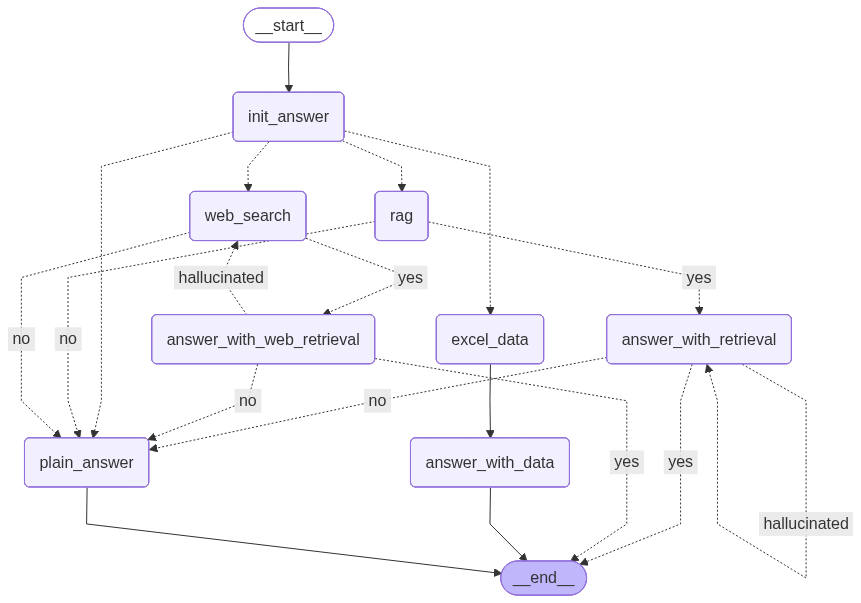

In [14]:
from IPython.display import Image, display

# LangGraph가 제공하는 Mermaid 렌더링 기능을 사용해 그래프 구조를 이미지로 출력합니다.
display(Image(graph.get_graph().draw_mermaid_png()))

모델 구성을 끝마쳤으면, 한번 사용해 봅시다.

Note. LLM 특성상 의도하지 않은 방식으로 작동하지 않을 가능성이 있습니다.

In [18]:
while True:
    question = input("질문을 입력해주세요 (종료를 원하시면 '종료'를 입력해주세요.): ")
    if question == "종료":
        break
    else:
        print("="*20)
        print("질문 :", question)
        # graph.invoke 함수를 사용하여 그래프를 실행하고, 최종 결과를 반환합니다.
        # 답변 생성에는 약 1분 정도 소요됩니다.
        try:
            print(
                "Assistant: ",
                graph.invoke({"question": question})["generation"],
            )
        except Exception as e:
            print("Assistant: 오류가 발생했습니다. 다시 시도해주세요.")
            print(e)

질문 : 데이터 구축 현황 자료에 등록된 분야(도메인)는 총 몇 가지이고, 각 분야별 구축 건수는 어떻게 되나요?
---데이터 쿼리---

import pandas as pd

# 데이터프레임에 액세스할 수 있도록 설정합니다.
df_ai_train_data_dist = pd.read_csv('데이터 로드 경로')  # 데이터 로드 코드를 생략했습니다.

# 각 분야별 구축 건수를 확인하기 위해 그룹화하여 카운트합니다.
domain_count = df_ai_train_data_dist.groupby('분야')['연도'].count().reset_index()

# 총 분야 수를 확인합니다.
total_domain = domain_count['분야'].nunique()

print(f"총 분야 수: {total_domain}")
print("각 분야별 구축 건수:")
print(domain_count)

---데이터 기반 답변 생성---
Assistant:  이러한 오류 메시지는 파일이 존재하지 않거나, 지정된 경로가 올바르지 않은 경우 발생하는 에러입니다.

데이터 로드 경로에 대한 정보를 가지고 있지 않아, 데이터 구축 현황 자료에 등록된 분야(도메인)와 각 분야별 구축 건수를 알려드릴 수 없습니다. 

하지만, 일반적으로 데이터 분석에서 이러한 오류는 파일 경로나 이름이 잘못되었을 때 발생하므로, 확인해 보시고 다시 시도하시면 좋을 것입니다.

만약, 데이터 로드 경로가 올바르지 않다면, 해당 경로에 파일이 존재하는지 확인하고, 파일 이름과 확장자를 확인하여 올바른 파일을 선택하시기 바랍니다.
질문 : 2023년 기준 국내 인공지능 산업의 주요 동향과 성장 배경은 무엇인가요?
---데이터 검색---
[RAG 검색 결과] ./data/RE177_2023년 국내외 인공지능 산업 동향 연구_2장.pdf | - 4 -
제2장인공지능산업현황및전망제1절AI 산업 현황 1.전 세계 AI 현황 및 수준2023년 4월, 미국 스탠포드 대학의 HAI는 2023...
[RAG 

### 라우팅 경로별 예상 질문 및 답변 예시

`init_answer` 노드는 질문을 `excel_data`, `rag`, `web_search`, `plain_answer` 중 하나로 분류합니다. 각 경로가 실제로 선택될 만한 질문과, 해당 경로를 거쳤을 때 예상되는 답변의 형태를 정리하면 다음과 같습니다. (아래 예시는 모두 ChatGPT API 기준으로 `graph.invoke()`를 직접 실행해 확인했습니다.)

**1. `excel_data` 경로** — 로드된 `df_ai_train_data_dist` (한국지능정보사회진흥원의 AI 학습용 데이터 구축 현황)에 대한 질문
- 예상 질문: "데이터 구축 현황 자료에 등록된 분야(도메인)는 총 몇 가지이고, 각 분야별 구축 건수는 어떻게 되나요?"
- 확인된 답변 흐름: `query` 노드가 `df_ai_train_data_dist.groupby(...)`류의 코드를 생성·실행해 총 114개 분야의 집계 결과를 얻고, `answer_with_data` 노드가 이를 바탕으로 분야별 구축 건수를 요약한 답변을 생성합니다.

**2. `rag` 경로** — 벡터스토어에 색인된 `2023년 국내외 인공지능 산업 동향 연구` PDF에 대한 질문
- 예상 질문: "2023년 기준 국내 인공지능 산업의 주요 동향과 성장 배경은 무엇인가요?"
- 확인된 답변 흐름: `retrieval` 노드가 Chroma 벡터스토어에서 관련 문서를 검색합니다. 다만 `is_data_relevant` 평가에서 검색된 청크가 질문과 직접 관련이 없다고 판단되면(`relevant: false`) `plain_answer`로 이동해 일반 지식으로 답합니다. 관련성이 있다고 판단되면 `answer_with_retrieval` 노드가 검색된 문서 내용을 근거로 답변을 생성합니다.

**3. `web_search` 경로** — 로컬 데이터(엑셀/PDF)에 없는, 최신 정보나 외부 지식이 필요한 질문
- 예상 질문: "오늘 서울 날씨가 어때?"
- 확인된 답변 흐름: `retrieve_web` 노드가 Tavily 웹 검색으로 최신 날씨 정보 1건을 가져오고, `is_data_relevant`(관련 있음) → `answer_with_web_retrieval`(답변 생성) → `judge_answer`(할루시네이션/지지/유용성 모두 통과)를 거쳐 실제 기온·습도 등을 포함한 답변이 생성되는 것을 확인했습니다. 할루시네이션이 의심되면 답변을 재생성하는 대신 `web_search`로 되돌아가 재검색합니다.

**4. `plain_answer` 경로** — 검색이 필요 없는 일반적인 질문
- 예상 질문: "인공지능이 뭐야?"
- 확인된 답변 흐름: 검색 없이 `answer` 노드가 `llm`으로 바로 일반적인 AI 정의를 답합니다.

> 참고: 실제 라우팅 결과는 `route_llm`(ChatGPT API, `.env`의 `MODEL_NAME`)이 질문을 어떻게 해석하느냐에 따라 달라질 수 있습니다. 예를 들어 "최근 공개된 오픈소스 LLM은?"과 같이 애매한 질문은 `rag`로도, `web_search`로도 분류될 수 있습니다. 위 질문들은 각 경로로 안정적으로 라우팅되는 것을 실제로 확인한 예시입니다.